# Glabal land Temperature 

En este notebook se exploran algunas tecnicas para el preprocesamiento de los datos, en este caso los datos que tenemos son CSV, el cual nos da la temperatura promedio a lo largo del tiempo en varios lugares del mundo. 
Nos ayudamos de tecnicas como filtrado, algunas funciones para realizar la correcta visualización de datos.

## Carga de datos 

In [1]:
import pandas as pd
df = pd.read_csv(r'GLT_filtrado.csv', encoding='utf-8')

## Exploración de datos

Usamos algunas funciones de pandas, y otras de python para poder hacer la exploración de los datos como el tipo de datos, los datos nulos, la media, la desviasión estándar, los mímimos o máximos, etc. 

In [2]:
print(type(df))

<class 'pandas.DataFrame'>


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 219575 entries, 0 to 219574
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           219575 non-null  str    
 1   AverageTemperature             191994 non-null  float64
 2   AverageTemperatureUncertainty  191994 non-null  float64
 3   City                           219575 non-null  str    
 4   Country                        219575 non-null  str    
 5   Latitude                       219575 non-null  str    
 6   Longitude                      219575 non-null  str    
dtypes: float64(2), str(5)
memory usage: 11.7 MB


In [4]:
df.describe()

,AverageTemperature,AverageTemperatureUncertainty
count,191994.000000,191994.000000
mean,19.074293,1.148474
std,11.705712,3.374958
min,-26.772000,0.049000
25%,13.399000,0.329000
50%,20.857000,0.549000
75%,26.112000,1.151000
max,88.007000,41.588600


In [5]:
df.dtypes

Date                                 str
AverageTemperature               float64
AverageTemperatureUncertainty    float64
City                                 str
Country                              str
Latitude                             str
Longitude                            str
dtype: object

In [6]:
df.isnull().sum()

Date                                 0
AverageTemperature               27581
AverageTemperatureUncertainty    27581
City                                 0
Country                              0
Latitude                             0
Longitude                            0
dtype: int64

## 3. Convierte la columna Date de texto a una fecha (datetime)

Aquí vamos a tener que manipular el tiempo así que podemos ayudarnos con una función que ayuda a referirnos a las fechas

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
...,...,...,...,...,...,...,...,...
219570,2012-08-01,23.885,0.435,Xian,China,34.56N,108.97E,2012
219571,2012-09-01,17.028,1.405,Xian,China,34.56N,108.97E,2012
219572,2012-10-01,12.399,0.526,Xian,China,34.56N,108.97E,2012
219573,2012-11-01,4.736,0.519,Xian,China,34.56N,108.97E,2012


## 4. Filtra una ciudad

Quizás tengamos que aplicar un filtro, así que vamos a usar una función 

In [8]:
ciudad = 'Mexico'
d = df[df['City'] == ciudad]
print("Filas:", len(d))
d

Filas: 2136


,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year
135993,1835-01-01,13.086,1.942,Mexico,Mexico,20.09N,98.96W,1835
135994,1835-02-01,12.322,2.020,Mexico,Mexico,20.09N,98.96W,1835
135995,1835-03-01,13.874,2.271,Mexico,Mexico,20.09N,98.96W,1835
135996,1835-04-01,16.312,2.247,Mexico,Mexico,20.09N,98.96W,1835
135997,1835-05-01,NaN,NaN,Mexico,Mexico,20.09N,98.96W,1835
...,...,...,...,...,...,...,...,...
138124,2012-08-01,17.764,0.446,Mexico,Mexico,20.09N,98.96W,2012
138125,2012-09-01,17.374,0.364,Mexico,Mexico,20.09N,98.96W,2012
138126,2012-10-01,16.844,0.452,Mexico,Mexico,20.09N,98.96W,2012
138127,2012-11-01,14.009,0.330,Mexico,Mexico,20.09N,98.96W,2012


## 5. Calcula la temperatura media anual:

Vamos a calcular la media anual dado el filtro, pero para ello necesitamos conocer algunas funciones de pandas, como poder realizarnos nosotros mismos

In [9]:
for i in d["Year"].unique():
  data_for_year_i = d[d['Year'] == i]
  print(data_for_year_i['AverageTemperature'].mean())

13.847818181818178
15.4652
14.822583333333332
14.480333333333336
14.575444444444445
15.269899999999998
15.033800000000003
15.363166666666666
15.294454545454546
14.983583333333334
14.689300000000003
15.6385
15.318636363636363
15.181416666666664
15.729999999999999
15.53009090909091
15.366416666666668
15.318999999999999
14.949083333333332
15.223700000000003
14.833416666666666
14.724416666666668
15.150727272727277
15.286454545454546
15.711416666666665
15.532909090909088
15.898272727272728
15.489833333333335
15.214999999999996
15.254636363636365
15.514916666666666
15.704699999999997
15.799555555555555
15.25975
15.549
15.428777777777778
15.577666666666664
15.47458333333333
15.857454545454546
15.231800000000002
15.305583333333331
14.9387
15.779818181818182
15.94075
15.629333333333332
15.133111111111113
15.584333333333332
15.403250000000002
15.169333333333334
14.876454545454548
15.503999999999998
15.579454545454546
14.951166666666667
15.0161
15.439083333333334
14.715181818181817
15.05791666666

In [10]:
media_anual = d.groupby('Year')['AverageTemperature'].mean()
print(media_anual)

Year
1835    13.847818
1836    15.465200
1837    14.822583
1838    14.480333
1839    14.575444
          ...    
2008    16.469091
2009    16.704556
2010    16.009100
2011    16.613455
2012    16.426500
Name: AverageTemperature, Length: 178, dtype: float64



## 6. Grafica el resultado:

Siempre es importante gráficar los datos para ver como fue nuestro proceso, o como va la tendencia.

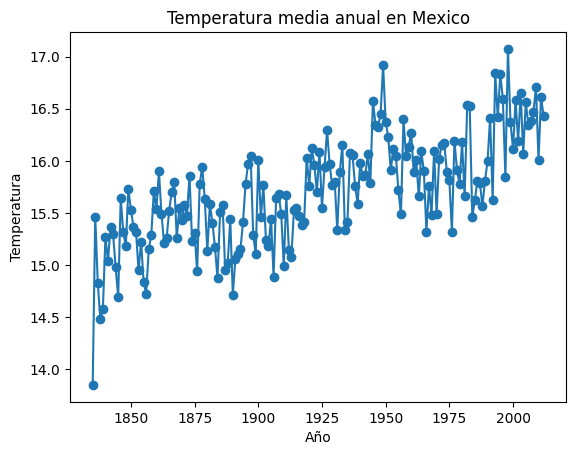

In [11]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(media_anual.index, media_anual.values, marker='o')
plt.plot()
plt.title(f'Temperatura media anual en Mexico')
plt.xlabel('Año')
plt.ylabel('Temperatura')
plt.show()

In [12]:
media_anual = d.groupby('Year')['AverageTemperature'].mean().dropna()
X = media_anual.index.values.reshape(-1, 1)
y = media_anual.values
X_norm = (X - X.min()) / (X.max() - X.min())